# Primary model — 2026 backtest (all decided races)

**Question:** how has the primary nominee model done on every 2026 primary that has already happened?

- **Predictions**: `primary_predictions_2026.csv` — the model's output from pre-primary polls only
  (each decided race's primary polls end at its primary, so this approximates the primary-eve forecast).
- **Ground truth**: `data/primary_results_2026.csv` — ACTUAL primary winners scraped from Wikipedia
  results tables (runoffs supersede round one). No general-election information is used anywhere.
- **Baseline**: the poll leader (candidate with the highest raw polling average).

Caveats: the dropped-out candidate list encodes a little post-hoc knowledge; races without parsed
results or with a single polled candidate are excluded (counted in cell 1); House races are
extrapolation (training data is Senate+Governor 2018-2024) and hold every high-confidence miss.

In [1]:
# setup: run from analysis/, repo root is one level up
import os, sys
if os.path.basename(os.getcwd()) == "analysis":
    os.chdir("..")
sys.path.insert(0, ".")
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, brier_score_loss
import features as F
from features_primary import merge_nickname_aliases
pd.set_option("display.max_colwidth", 40)

AS_OF = pd.Timestamp("2026-07-15")   # scoring date: primaries before this are "decided"

# predictions: local run output, else the committed polling-agg copy
PREDS = ("primary_predictions_2026.csv" if os.path.exists("primary_predictions_2026.csv")
         else os.path.join("..", "Polling Agg", "Polling agg and Prediction markets",
                           "data", "processed", "model_primary_predictions_2026.csv"))
p = pd.read_csv(PREDS)
p["ed"] = pd.to_datetime(p["election_date"], errors="coerce")
past = p[p["ed"] < AS_OF].copy()
past["cand_key"] = past["candidate"].map(F.norm_name)
past, _ = merge_nickname_aliases(past)   # same aliasing as the pipeline

res = pd.read_csv("data/primary_results_2026.csv")   # scraped ACTUAL primary winners
winners = {}
for r in res[res["is_winner"]].itertuples():
    winners.setdefault(r.race_id, set()).add(r.cand_key)
print(f"decided primary races with predictions: {past['race_id'].nunique()} | "
      f"races with parsed results: {len(winners)}")

decided primary races with predictions: 106 | races with parsed results: 397


In [2]:
# score every contested decided race against the actual winner
def match_winner(wset, field):
    """Exact key match, else unique-last-name fallback (Bobby vs Robert Charles)."""
    hit = wset & field
    if hit:
        return hit
    out = set()
    for w in wset:
        last = w.split(" ")[0]
        same = {k for k in field if k.split(" ")[0] == last}
        if len(same) == 1:
            out |= same
    return out

rows = []
for rid, g in past.groupby("race_id"):
    if rid not in winners:
        continue
    g = g.sort_values("win_prob", ascending=False).drop_duplicates("cand_key").copy()
    wm = match_winner(winners[rid], set(g["cand_key"]))
    g["won"] = g["cand_key"].isin(wm).astype(int)
    if len(g) < 2:
        continue                      # uncontested: nothing to predict
    pick = g.loc[g["win_prob"].idxmax()]
    pleader = g.loc[g["poll_avg"].idxmax()]
    rows.append(dict(
        race_id=rid, office=g["office"].iloc[0], party=g["party"].iloc[0],
        month=str(g["ed"].iloc[0])[:7], n_cand=len(g),
        n_surveys=int(g["n_surveys"].iloc[0]),
        pick=pick["candidate"], pick_prob=float(pick["win_prob_norm"]),
        correct=int(pick["won"] == 1),
        poll_leader=pleader["candidate"], pl_correct=int(pleader["won"] == 1),
        diverged=int(pick["cand_key"] != pleader["cand_key"]),
        winner=", ".join(g.loc[g["won"] == 1, "candidate"]) or "(unpolled)",
        cands=g))
rd = pd.DataFrame([{k: v for k, v in r.items() if k != "cands"} for r in rows])
allc = pd.concat([r["cands"] for r in rows])
print(f"contested decided races scored: {len(rd)}")
print(f"MODEL pick accuracy : {rd.correct.mean():.1%}  ({rd.correct.sum()}/{len(rd)})")
print(f"poll-leader accuracy: {rd.pl_correct.mean():.1%}  ({rd.pl_correct.sum()}/{len(rd)})")
print(f"candidate-level AUC {roc_auc_score(allc.won, allc.win_prob_norm):.3f} | "
      f"Brier {brier_score_loss(allc.won, allc.win_prob_norm):.3f}")

contested decided races scored: 84
MODEL pick accuracy : 81.0%  (68/84)
poll-leader accuracy: 67.9%  (57/84)
candidate-level AUC 0.962 | Brier 0.058


## Splits

In [3]:
# splits: office / party / month
for dim in ["office", "party", "month"]:
    t = rd.groupby(dim).agg(races=("correct", "size"), model=("correct", "mean"),
                            poll_leader=("pl_correct", "mean")).round(3)
    display(t)

,races,model,poll_leader
office,,,
Governor,20,0.850,0.750
House,45,0.756,0.622
Senate,19,0.895,0.737


,races,model,poll_leader
party,,,
DEM,42,0.81,0.619
REP,42,0.81,0.738


,races,model,poll_leader
month,,,
2026-05,37,0.730,0.595
2026-06,47,0.872,0.745


## Where the model disagreed with the polls

This is the value-add test: anyone can read a polling average.

In [4]:
# THE value-add stat: races where the model DISAGREED with the poll leader
d = rd[rd.diverged == 1].copy()
d["outcome"] = d.apply(lambda r: "MODEL RIGHT" if r.correct else
                       ("POLLS RIGHT" if r.pl_correct else "BOTH WRONG"), axis=1)
print(f"disagreements: {len(d)} | model right {int(d.correct.sum())} | "
      f"polls right {int(d.pl_correct.sum())} | both wrong "
      f"{int(((d.correct==0)&(d.pl_correct==0)).sum())}")
d[["race_id", "outcome", "pick", "pick_prob", "poll_leader", "winner", "n_surveys"]] \
    .sort_values(["outcome", "pick_prob"], ascending=[True, False]) \
    .reset_index(drop=True)

disagreements: 19 | model right 14 | polls right 3 | both wrong 2


,race_id,outcome,pick,pick_prob,poll_leader,winner,n_surveys
0,2026_AL_Senate_REP,BOTH WRONG,Jared Hudson,0.421032,Steve Marshall,Barry Moore,24
1,2026_SD_Governor_REP,BOTH WRONG,Larry R. Rhoden,0.364090,Dusty Johnson,Toby Doeden,13
2,2026_GA_Governor_DEM,MODEL RIGHT,Keisha Lance Bottoms,0.950972,Stacey Abrams,Keisha Lance Bottoms,13
3,2026_IA_Senate_DEM,MODEL RIGHT,Josh Turek,0.852706,Jackie Norris,Josh Turek,17
4,2026_NC_Senate_REP,MODEL RIGHT,Michael Whatley,0.850244,Lara Trump,Michael Whatley,27
5,2026_IA_Governor_REP,MODEL RIGHT,Zach Lahn,0.815204,Randy Feenstra,Zach Lahn,9
6,2026_IA_House-3_DEM,MODEL RIGHT,Sarah Trone Garriott,0.803837,Jennifer Konfrst,Sarah Trone Garriott,2
7,2026_SC_House-1_REP,MODEL RIGHT,Jenny Costa Honeycutt,0.757634,Mark Smith,Jenny Costa Honeycutt,3
8,2026_PA_House-7_DEM,MODEL RIGHT,Bob Brooks,0.728020,Lamont McClure,Bob Brooks,5
9,2026_TX_Senate_DEM,MODEL RIGHT,James Talarico,0.600666,Jasmine Crockett,James Talarico,48


## Calibration

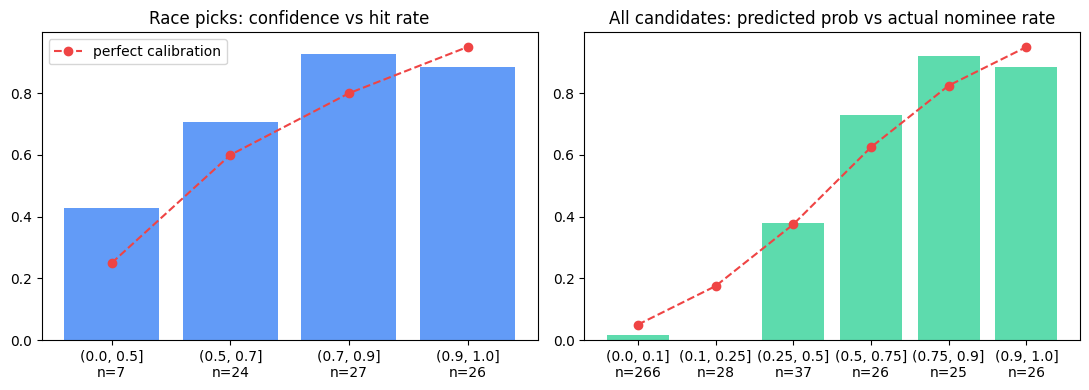

,n,hit
band,,
"(0.0, 0.5]",7,0.429
"(0.5, 0.7]",24,0.708
"(0.7, 0.9]",27,0.926
"(0.9, 1.0]",26,0.885


,n,actual
bucket,,
"(0.0, 0.1]",266,0.015
"(0.1, 0.25]",28,0.000
"(0.25, 0.5]",37,0.378
"(0.5, 0.75]",26,0.731
"(0.75, 0.9]",25,0.920
"(0.9, 1.0]",26,0.885


In [5]:
# calibration: model pick confidence vs hit rate + candidate-level reliability
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
rd["band"] = pd.cut(rd.pick_prob, [0, .5, .7, .9, 1.0])
t = rd.groupby("band", observed=True).agg(n=("correct", "size"), hit=("correct", "mean"))
axes[0].bar(range(len(t)), t.hit, color="#3b82f6", alpha=.8)
axes[0].plot(range(len(t)), [i.mid for i in t.index], "o--", color="#ef4444",
             label="perfect calibration")
axes[0].set_xticks(range(len(t)), [f"{i}\nn={n}" for i, n in zip(t.index.astype(str), t.n)])
axes[0].set_title("Race picks: confidence vs hit rate"); axes[0].legend()
allc["bucket"] = pd.cut(allc.win_prob_norm, [0, .1, .25, .5, .75, .9, 1.0])
t2 = allc.groupby("bucket", observed=True).agg(n=("won", "size"), actual=("won", "mean"))
axes[1].bar(range(len(t2)), t2.actual, color="#34d399", alpha=.8)
axes[1].plot(range(len(t2)), [i.mid for i in t2.index], "o--", color="#ef4444")
axes[1].set_xticks(range(len(t2)),
                   [f"{i}\nn={n}" for i, n in zip(t2.index.astype(str), t2.n)])
axes[1].set_title("All candidates: predicted prob vs actual nominee rate")
plt.tight_layout(); plt.show()
display(t.round(3)); display(t2.round(3))

## Misses

In [6]:
# every miss, by model confidence (high-confidence misses are ALL House races -
# the office absent from the 2018-24 training data; treat House probs as softer)
rd[rd.correct == 0][["race_id", "pick", "pick_prob", "poll_leader", "winner",
                     "n_surveys"]] \
    .sort_values("pick_prob", ascending=False).reset_index(drop=True)

,race_id,pick,pick_prob,poll_leader,winner,n_surveys
0,2026_NE_House-2_DEM,John Cavanaugh,0.961969,John Cavanaugh,Denise Powell,2
1,2026_TX_House-34_REP,Mayra Flores,0.920145,Mayra Flores,Eric Flores,1
2,2026_TX_House-32_REP,Katrina Pierson,0.905569,Katrina Pierson,(unpolled),1
3,2026_TX_House-2_REP,Dan Crenshaw,0.858440,Dan Crenshaw,Steve Toth,1
4,2026_KY_House-6_DEM,Cherlynn Stevenson,0.853530,Cherlynn Stevenson,Zach Dembo,2
5,2026_NY_House-7_DEM,Antonio Reynoso,0.634014,Antonio Reynoso,Claire Valdez,2
6,2026_CO_Governor_DEM,Michael Bennet,0.613567,Michael Bennet,Phil Weiser,9
7,2026_TX_House-9_REP,Briscoe Cain,0.579453,Briscoe Cain,Alex Mealer,6
8,2026_NY_House-13_DEM,Adriano Espaillat,0.530753,Adriano Espaillat,Darializa Avila Chevalier,4
9,2026_GA_House-13_DEM,David Scott,0.522616,David Scott,Jasmine Clark,1


## Full table

In [7]:
# the full scored table (sortable in Jupyter)
rd.drop(columns=["band"]).sort_values(["month", "race_id"]).reset_index(drop=True)

,race_id,office,party,month,n_cand,n_surveys,pick,pick_prob,correct,poll_leader,pl_correct,diverged,winner
0,2026_AL_Governor_REP,Governor,REP,2026-05,3,4,Tommy Tuberville,0.982412,1,Tommy Tuberville,1,0,Tommy Tuberville
1,2026_AL_House-1_REP,House,REP,2026-05,7,10,Jerry Carl,0.620210,1,Jerry Carl,1,0,Jerry Carl
2,2026_AL_Senate_REP,Senate,REP,2026-05,8,24,Jared Hudson,0.421032,0,Steve Marshall,0,1,Barry Moore
3,2026_GA_Governor_DEM,Governor,DEM,2026-05,9,13,Keisha Lance Bottoms,0.950972,1,Stacey Abrams,0,1,Keisha Lance Bottoms
4,2026_GA_Governor_REP,Governor,REP,2026-05,11,30,Rick Jackson,0.754082,1,Rick Jackson,1,0,Rick Jackson
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,2026_SC_Senate_REP,Senate,REP,2026-06,6,13,Lindsey Graham,0.733592,1,Lindsey Graham,1,0,Lindsey Graham
80,2026_SD_Governor_REP,Governor,REP,2026-06,4,13,Larry R. Rhoden,0.364090,0,Dusty Johnson,0,1,Toby Doeden
81,2026_SD_Senate_REP,Senate,REP,2026-06,2,3,Mike Rounds,0.954259,1,Mike Rounds,1,0,Mike Rounds
82,2026_UT_House-1_DEM,House,DEM,2026-06,4,2,Ben McAdams,0.695091,1,Ben McAdams,1,0,Ben McAdams
